# K-Nearest Neighbors (KNN) with Different Distance Metrics (Iris Dataset)

This notebook implements KNN classification using multiple distance formulas and compares their performance.

Dataset used: **Iris Dataset** (multiclass classification).

Distance metrics compared:
- Euclidean Distance
- Manhattan Distance
- Minkowski Distance
- Cosine Distance

Evaluation metrics:
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt

## 2. Load Dataset

In [2]:
data = load_iris()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print('Dataset shape:', X.shape)
X.head()

Dataset shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 3. Train-Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 4. Evaluation Function

In [4]:
def evaluate_model(name, y_true, y_pred):
    print('---', name, '---')
    print('Accuracy:', accuracy_score(y_true, y_pred))
    print('Precision:', precision_score(y_true, y_pred, average='macro'))
    print('Recall:', recall_score(y_true, y_pred, average='macro'))
    print('F1 Score:', f1_score(y_true, y_pred, average='macro'))
    print('Confusion Matrix:\n', confusion_matrix(y_true, y_pred))
    print('\n')

## 5. Train KNN with Different Distance Metrics

In [5]:
# Euclidean Distance
knn_euclidean = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_euclidean.fit(X_train, y_train)
pred_euclidean = knn_euclidean.predict(X_test)

# Manhattan Distance
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(X_train, y_train)
pred_manhattan = knn_manhattan.predict(X_test)

# Minkowski Distance
knn_minkowski = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=3)
knn_minkowski.fit(X_train, y_train)
pred_minkowski = knn_minkowski.predict(X_test)

# Cosine Distance
knn_cosine = KNeighborsClassifier(n_neighbors=5, metric='cosine')
knn_cosine.fit(X_train, y_train)
pred_cosine = knn_cosine.predict(X_test)

## 6. Compare Results

In [6]:
evaluate_model('Euclidean', y_test, pred_euclidean)
evaluate_model('Manhattan', y_test, pred_manhattan)
evaluate_model('Minkowski', y_test, pred_minkowski)
evaluate_model('Cosine', y_test, pred_cosine)

--- Euclidean ---
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


--- Manhattan ---
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


--- Minkowski ---
Accuracy: 0.9666666666666667
Precision: 0.9722222222222222
Recall: 0.9629629629629629
F1 Score: 0.9658994032395567
Confusion Matrix:
 [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


--- Cosine ---
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]




## 7. Accuracy Comparison Plot

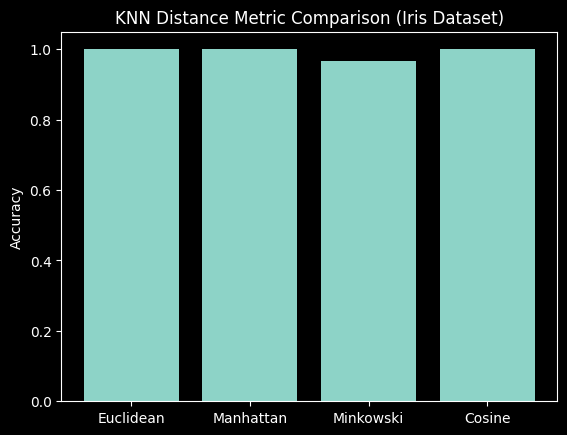

In [7]:
accuracies = [
    accuracy_score(y_test, pred_euclidean),
    accuracy_score(y_test, pred_manhattan),
    accuracy_score(y_test, pred_minkowski),
    accuracy_score(y_test, pred_cosine)
]

labels = ['Euclidean','Manhattan','Minkowski','Cosine']

plt.bar(labels, accuracies)
plt.ylabel('Accuracy')
plt.title('KNN Distance Metric Comparison (Iris Dataset)')
plt.show()

## 8. Conclusion

- Euclidean distance is commonly used for KNN.
- Manhattan distance can sometimes perform better when features behave independently.
- Minkowski generalizes both Euclidean and Manhattan.
- Cosine distance measures similarity in direction rather than magnitude.
- Performance differences depend heavily on dataset structure.